شروع آموزش مدل...
Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4323 - loss: 0.7869 - val_accuracy: 0.4685 - val_loss: 0.7524
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5888 - loss: 0.7394 - val_accuracy: 0.6503 - val_loss: 0.7118
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6186 - loss: 0.7028 - val_accuracy: 0.6503 - val_loss: 0.6769
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6292 - loss: 0.6727 - val_accuracy: 0.6434 - val_loss: 0.6436
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6309 - loss: 0.6433 - val_accuracy: 0.6503 - val_loss: 0.6132
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6397 - loss: 0.6174 - val_accuracy: 0.6434 - val_loss: 0.5822
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6415 - loss: 0.5914 - val_accuracy: 0.6434 - val_loss: 0.5509
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6784 - loss: 0.5640 - val_accuracy:

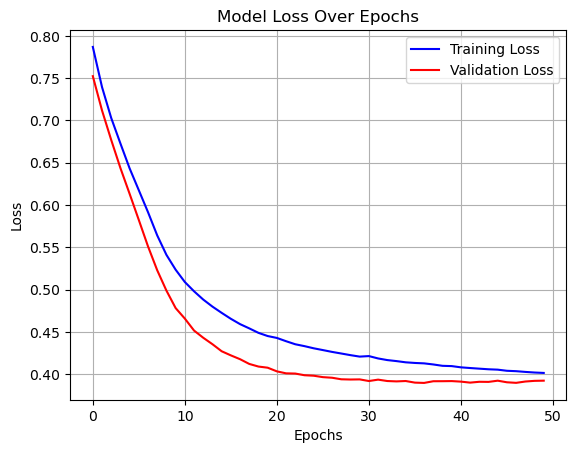

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. بارگذاری داده 
df = pd.read_csv('titanic.csv')

# 2. پیش‌پردازش داده‌ها
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[features].copy()
y = df['Survived']

# پر کردن مقادیر گمشده
X['Age'] = X['Age'].fillna(X['Age'].median())
X['Fare'] = X['Fare'].fillna(X['Fare'].median())

# تبدیل داده‌های متنی به عددی
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})

# 3. تقسیم به داده‌های آموزش و آزمون
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# استانداردسازی داده‌ها (جلوگیری از نشت داده)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. ساخت مدل شبکه عصبی برای طبقه‌بندی دودویی
model = keras.Sequential([
    layers.Input(shape=[X_train.shape[1]]),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid') 
])

# 5. کامپایل کردن مدل
model.compile(
    loss='binary_crossentropy', # تابع هزینه مخصوص طبقه‌بندی 0 و 1
    optimizer='adam',
    metrics=['accuracy']
)

# 6. آموزش مدل
print("شروع آموزش مدل...")
history = model.fit(
    X_train_scaled, 
    y_train, 
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# 7. ارزیابی مدل
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=1)
print("\nارزیابی مدل روی داده‌های تست:")
print(f"Accuracy: {accuracy * 100:.2f}%")

# 8. رسم نمودار
# استخراج داده‌های خطا
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# رسم خطوط نمودار
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')

# تنظیمات ظاهری نمودار
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend() # نمایش راهنمای نمودار
plt.grid(True) # نمایش شبکه پس‌زمینه

# نمایش نهایی نمودار
plt.show()
